# Анализ пассажиропотока: кластеризация + бейзлайн-прогноз
Данные: проходы метро/НГПТ/МЦД, часовая агрегация

In [71]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import os, gc, warnings, zipfile, re
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from datetime import timedelta

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (16, 5), 'font.size': 11})

## Загрузка архива

In [72]:
import gdown
file_id = '1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'data.zip', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM
From (redirected): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM&confirm=t&uuid=275300e8-3ec2-4349-b0f0-a195403f22d2
To: /kaggle/working/data.zip
100%|██████████| 2.51G/2.51G [00:52<00:00, 48.1MB/s]


'data.zip'

In [73]:
DATA_DIR = './data/'

with zipfile.ZipFile('/kaggle/working/data.zip', 'r') as z:
    z.extractall(DATA_DIR)
with zipfile.ZipFile('/kaggle/working/data/Метро НБС/pass_10-160324.zip', 'r') as z:
    z.extractall(DATA_DIR)

## 1. Справочники

In [74]:
ref_places = pd.read_csv(f'{DATA_DIR}REF_PSG_PLACES_202503251822.csv', sep=';')
ref_transport = pd.read_csv(f'{DATA_DIR}REF_TRANSPORT_TYPE_202503251727.csv', sep=';')
ref_routes = pd.read_csv(f'{DATA_DIR}REF_TRANSPORT_WAY_202503251803.csv', sep=';')
gds_goods = pd.read_csv(f'{DATA_DIR}GDS_GOODS_202503251844.csv', sep=';')
gds_app = pd.read_csv(f'{DATA_DIR}GDS_APPLICATION_202503251731.csv', sep=';')
gds_transfer = pd.read_csv(f'{DATA_DIR}GDS_TRANSFER_202503251738.csv', sep=';')

# контрагенты — кривой формат, парсим руками
rows = []
with open(f'{DATA_DIR}V_PCR_CONTRACTOR_202503251702.csv', 'r', encoding='utf-8') as f:
    for line in f:
        for m in re.findall(r'(\d+);;([^0-9]+?)(?=\d+;;|$)', line):
            rows.append({'ID': int(m[0]), 'PARENT_ID': None, 'NAME_SHORT': m[1].strip()})
pcr_contr = pd.DataFrame(rows)

print(f"ref_places: {len(ref_places)}, ref_transport: {len(ref_transport)}, "
      f"ref_routes: {len(ref_routes)}, gds_goods: {len(gds_goods)}, pcr_contr: {len(pcr_contr)}")

ref_places: 3141, ref_transport: 10, ref_routes: 2490, gds_goods: 432, pcr_contr: 2121


## 2. Чанковая загрузка pass_all → часовая агрегация
Файл ~12 ГБ, в RAM не влезет целиком. Читаем кусками, сразу агрегируем.

In [75]:
USE_COLS = ['TRAN_DATE','PLACE_ID','TRANSPORT_TYPE_ID','BUS_RT_NO',
            'AGENT_ID','GD_ID','TRANSFER_TYPE_ID','VALIDATION_MODE',
            'CPPC_VALIDATION_TYPE','IS_FAIL','CRD_NO']

GROUP_KEYS = ['date_hour','PLACE_ID','TRANSPORT_TYPE_ID','BUS_RT_NO',
              'AGENT_ID','GD_ID','TRANSFER_TYPE_ID','VALIDATION_MODE',
              'CPPC_VALIDATION_TYPE']

CHUNK = 3_000_000
agg_parts = []
n_total = 0

reader = pd.read_csv(f'{DATA_DIR}PASS_ALL_202503242210.csv', sep=';',
                     usecols=USE_COLS, parse_dates=['TRAN_DATE'],
                     chunksize=CHUNK, low_memory=False)

for i, ch in enumerate(reader):
    n_total += len(ch)
    ch = ch[ch['IS_FAIL'] != 1].copy()
    ch['date_hour'] = ch['TRAN_DATE'].dt.floor('h')
    agg = ch.groupby(GROUP_KEYS, dropna=False).agg(
        pax=('TRAN_DATE', 'size'), unique_cards=('CRD_NO', 'nunique')
    ).reset_index()
    agg_parts.append(agg)
    del ch, agg; gc.collect()
    if (i+1) % 10 == 0:
        mem = sum(x.memory_usage(deep=True).sum() for x in agg_parts) / 1e9
        print(f"  chunk {i+1}: {n_total:,} строк, ~{mem:.2f} ГБ в RAM")

print(f"Итого строк: {n_total:,}")

hourly = pd.concat(agg_parts, ignore_index=True)
del agg_parts; gc.collect()
hourly = hourly.groupby(GROUP_KEYS, dropna=False).agg(
    pax=('pax','sum'), unique_cards=('unique_cards','sum')
).reset_index()

print(f"hourly: {len(hourly):,} строк, {hourly.memory_usage(deep=True).sum()/1e6:.0f} МБ")

  chunk 10: 30,000,000 строк, ~0.15 ГБ в RAM
  chunk 20: 60,000,000 строк, ~0.31 ГБ в RAM
  chunk 30: 89,150,313 строк, ~0.49 ГБ в RAM
Итого строк: 89,150,313
hourly: 4,982,384 строк, 438 МБ


## 3. Обогащение справочниками + временные фичи

In [76]:
# места
hourly = hourly.merge(
    ref_places[['PLACE_ID','TYPE_ID','ST_CODE','ST_NAME','LN_CODE','LN_NAME','IS_TEST']],
    on='PLACE_ID', how='left')
hourly = hourly[hourly['IS_TEST'] != 1].drop(columns='IS_TEST')

# транспорт
hourly = hourly.merge(
    ref_transport.rename(columns={'TRANSPORT_ID':'TRANSPORT_TYPE_ID','NAME':'TRANSPORT_NAME'}),
    on='TRANSPORT_TYPE_ID', how='left')

# маршруты
hourly = hourly.merge(
    ref_routes[['WAY_ID','NAME']].rename(columns={'WAY_ID':'BUS_RT_NO','NAME':'ROUTE_NAME'}),
    on='BUS_RT_NO', how='left')

# оператор
hourly = hourly.merge(
    pcr_contr[['ID','NAME_SHORT']].rename(columns={'ID':'AGENT_ID','NAME_SHORT':'AGENT_NAME'}),
    on='AGENT_ID', how='left')

# билеты
hourly = hourly.merge(
    gds_goods[['GD_ID','NAME_SHORT','ARCHITECT_ID']].rename(columns={'NAME_SHORT':'TICKET_NAME'}),
    on='GD_ID', how='left')

# категория транспорта
def transport_cat(row):
    if pd.notna(row['BUS_RT_NO']): return 'НГПТ'
    if row['TYPE_ID'] == 1: return 'Метро'
    if row['TYPE_ID'] == 15: return 'МЦД'
    return 'Другое'

hourly['tcat'] = hourly.apply(transport_cat, axis=1)
hourly['hour'] = hourly['date_hour'].dt.hour
hourly['date'] = hourly['date_hour'].dt.normalize()
hourly['dow'] = hourly['date_hour'].dt.dayofweek
hourly['month'] = hourly['date_hour'].dt.month
hourly['is_wknd'] = (hourly['dow'] >= 5).astype(int)

print(hourly.groupby('tcat')['pax'].sum().sort_values(ascending=False))

tcat
Метро    49532102
НГПТ     30591283
МЦД       9021493
Name: pax, dtype: int64


## 4. Построение профилей для кластеризации

In [77]:
def build_profiles(subset, id_col, name_col):
    """Часовой поведенческий профиль для каждого объекта."""
    subset = subset.copy()
    subset['is_wknd'] = (subset['dow'] >= 5).astype(int)
    rows = []
    for oid in subset[id_col].dropna().unique():
        d = subset[subset[id_col] == oid]
        name = d[name_col].iloc[0] if name_col in d.columns else '?'

        wd = d[d['is_wknd']==0]
        nd_wd = wd['date'].nunique()
        if nd_wd == 0: continue
        wd_h = wd.groupby('hour')['pax'].sum() / nd_wd
        wd_tot = wd_h.sum()
        if wd_tot == 0: continue

        we = d[d['is_wknd']==1]
        nd_we = we['date'].nunique()
        we_h = we.groupby('hour')['pax'].sum() / nd_we if nd_we > 0 else pd.Series(dtype=float)
        we_tot = we_h.sum() if nd_we > 0 else 0

        r = {'object_id': oid, 'object_name': name, 'daily_volume': wd_tot}
        for h in range(24):
            r[f'wd_h{h}'] = wd_h.get(h,0) / wd_tot
            r[f'we_h{h}'] = (we_h.get(h,0) / we_tot) if we_tot > 0 else 0

        morn = sum(wd_h.get(h,0) for h in [7,8,9])
        eve  = sum(wd_h.get(h,0) for h in [17,18,19])
        r['morn_eve_ratio'] = morn/eve if eve > 0 else 1.0
        r['we_wd_ratio'] = we_tot/wd_tot if wd_tot > 0 else 0
        r['peakiness'] = wd_h.max() / (wd_tot/24)
        r['night_share'] = sum(wd_h.get(h,0) for h in [23,0,1,2,3,4,5]) / wd_tot
        r['midday_share'] = sum(wd_h.get(h,0) for h in [11,12,13,14]) / wd_tot
        rows.append(r)
    return pd.DataFrame(rows)

# метро
metro = hourly[hourly['tcat']=='Метро']
metro_f = build_profiles(metro, 'ST_CODE', 'ST_NAME')
metro_f['transport'] = 'Метро'
st_map = metro.drop_duplicates('ST_CODE').set_index('ST_CODE')
metro_f['LN_CODE'] = metro_f['object_id'].map(st_map['LN_CODE'])
metro_f['LN_NAME'] = metro_f['object_id'].map(st_map['LN_NAME'])

# НГПТ
ngpt = hourly[hourly['tcat']=='НГПТ']
ngpt_f = build_profiles(ngpt, 'BUS_RT_NO', 'ROUTE_NAME')
ngpt_f['transport'] = 'НГПТ'
ngpt_f['LN_CODE'] = ngpt_f['LN_NAME'] = None

# МЦД
parts = [metro_f, ngpt_f]
mcd = hourly[hourly['tcat']=='МЦД']
if mcd['ST_CODE'].nunique() > 2:
    mcd_f = build_profiles(mcd, 'ST_CODE', 'ST_NAME')
    mcd_f['transport'] = 'МЦД'
    sm = mcd.drop_duplicates('ST_CODE').set_index('ST_CODE')
    mcd_f['LN_CODE'] = mcd_f['object_id'].map(sm['LN_CODE'])
    mcd_f['LN_NAME'] = mcd_f['object_id'].map(sm['LN_NAME'])
    parts.append(mcd_f)

all_feat = pd.concat(parts, ignore_index=True)
print(f"Всего объектов: {len(all_feat)}  "
      f"(Метро: {(all_feat.transport=='Метро').sum()}, "
      f"НГПТ: {(all_feat.transport=='НГПТ').sum()}, "
      f"МЦД: {(all_feat.transport=='МЦД').sum()})")

Всего объектов: 1646  (Метро: 314, НГПТ: 1035, МЦД: 297)


## 5. Чистка + кластеризация (KMeans)

После чистки: 1542


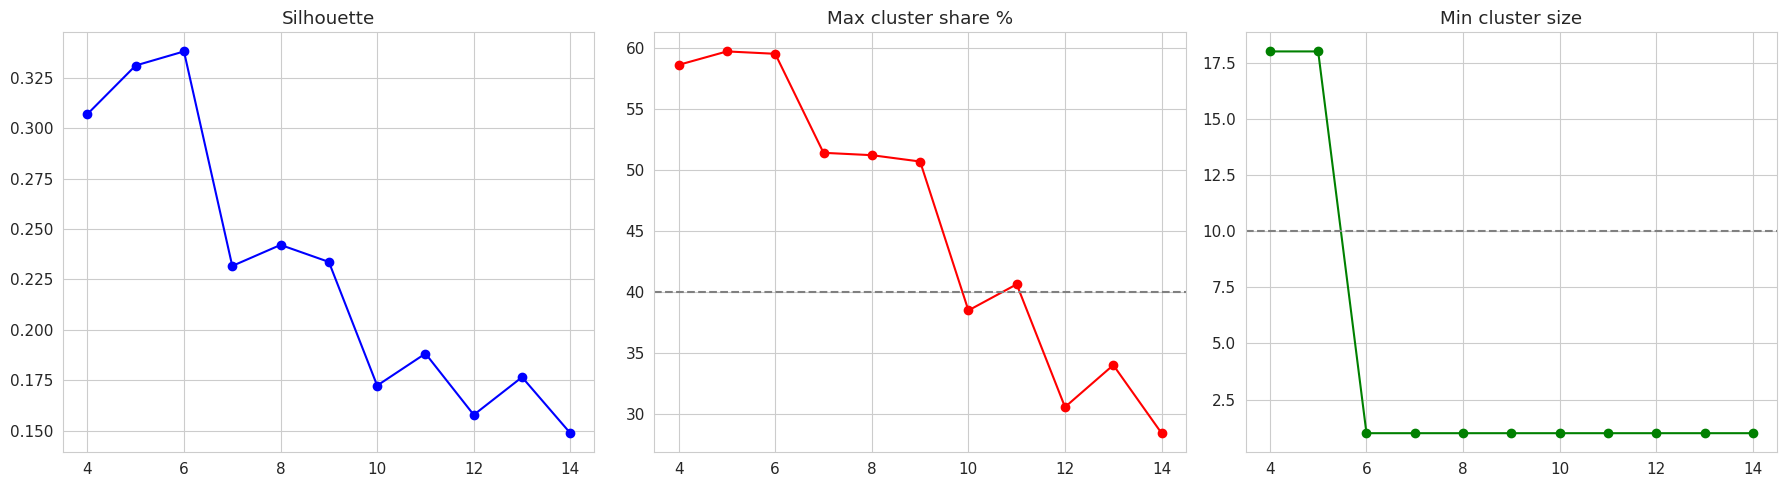

Выбрано k=11
 k      sil  min_cl  max_share
 4 0.306973      18   0.586252
 5 0.331091      18   0.597276
 6 0.338074       1   0.595331
 7 0.231674       1   0.514267
 8 0.242111       1   0.512322
 9 0.233680       1   0.507134
10 0.172355       1   0.385214
11 0.188229       1   0.406615
12 0.157829       1   0.306096
13 0.176526       1   0.340467
14 0.148738       1   0.284695


In [78]:
# фильтрация
af = all_feat[(all_feat['daily_volume'] >= 50) &
              (all_feat['peakiness'] < 15) &
              (all_feat['we_wd_ratio'] > 0)].copy()
af['object_name'] = af['object_name'].fillna(af['transport']+'_'+af['object_id'].astype(str))
print(f"После чистки: {len(af)}")

# признаки
af['log_volume'] = np.log1p(af['daily_volume'])
profile_cols = [f'wd_h{h}' for h in range(24)]
feat_cols = profile_cols + ['morn_eve_ratio','we_wd_ratio','peakiness',
                            'night_share','midday_share','log_volume']
X = StandardScaler().fit_transform(af[feat_cols].values)

# подбор k
res = []
for k in range(4, 15):
    lab = KMeans(k, n_init=30, random_state=42).fit_predict(X)
    sizes = pd.Series(lab).value_counts()
    res.append({'k': k, 'sil': silhouette_score(X, lab),
                'min_cl': sizes.min(), 'max_share': sizes.max()/len(lab)})
rdf = pd.DataFrame(res)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(rdf.k, rdf.sil, 'bo-'); axes[0].set_title('Silhouette')
axes[1].plot(rdf.k, rdf.max_share*100, 'ro-'); axes[1].axhline(40, c='gray', ls='--')
axes[1].set_title('Max cluster share %')
axes[2].plot(rdf.k, rdf.min_cl, 'go-'); axes[2].axhline(10, c='gray', ls='--')
axes[2].set_title('Min cluster size')
plt.tight_layout(); plt.savefig('./eda_output/clust_k_selection.png', dpi=150); plt.show()

# выбираем лучший k
good = rdf[(rdf.max_share < 0.40) & (rdf.min_cl >= 10)]
if len(good) == 0:
    good = rdf[rdf.max_share < 0.50]
best_k = int(good.loc[good.sil.idxmax(), 'k'])
print(f"Выбрано k={best_k}")
print(rdf.to_string(index=False))

In [79]:
# финальная кластеризация
km = KMeans(best_k, n_init=50, random_state=42)
af['cluster'] = km.fit_predict(X)

# мелкие кластеры (<10) сливаем с ближайшим крупным
sizes = af['cluster'].value_counts()
small = sizes[sizes < 10].index.tolist()
if small:
    centers = km.cluster_centers_
    for sc in small:
        dists = np.linalg.norm(centers - centers[sc], axis=1)
        dists[sc] = np.inf
        for s2 in small:
            if s2 != sc: dists[s2] = np.inf
        af.loc[af.cluster == sc, 'cluster'] = np.argmin(dists)
        print(f"  {sc} → {np.argmin(dists)}")
    mapping = {old: new for new, old in enumerate(sorted(af.cluster.unique()))}
    af['cluster'] = af.cluster.map(mapping)

final_k = af.cluster.nunique()
print(f"Итого кластеров: {final_k}")
print(af.cluster.value_counts().sort_index())

  7 → 0
  4 → 0
  8 → 1
Итого кластеров: 8
cluster
0     14
1    285
2    193
3    225
4    116
5     96
6    595
7     18
Name: count, dtype: int64


## 6. Профили кластеров

In [96]:
# описание кластеров
for c in sorted(af.cluster.unique()):
    s = af[af.cluster==c]
    me = s.morn_eve_ratio.mean()
    vol = s.daily_volume.mean()
    label = "ЖИЛОЙ" if me>1.3 else ("ДЕЛОВОЙ" if me<0.75 else "СМЕШАННЫЙ")
    if vol > 20000: label += " крупный"
    elif vol < 2000: label += " мелкий"
    n_m = (s.transport=='Метро').sum()
    n_n = (s.transport=='НГПТ').sum()
    n_d = (s.transport=='МЦД').sum()
    print(f"\nC{c} — {label}  [{len(s)} объектов: {n_m} {n_n} {n_d}]")
    print(f"  объём={vol:,.0f}/день  у/в={me:.2f}  вых/буд={s.we_wd_ratio.mean():.2f}")
    for _, r in s.nlargest(5, 'daily_volume').iterrows():
        icon = {'Метро':'','НГПТ':'','МЦД':''}[r.transport]
        print(f"    {icon} {r.object_name} ({r.daily_volume:,.0f}/д)")


C0 — СМЕШАННЫЙ мелкий  [14 объектов: 1 13 0]
  объём=1,381/день  у/в=0.78  вых/буд=0.79
     НГПТ_7383.0 (5,492/д)
     НГПТ_4003.0 (1,639/д)
     50К трамвай (1,631/д)
     НГПТ_4112.0 (1,504/д)
     Ш2 автобус (1,266/д)

C1 — СМЕШАННЫЙ  [285 объектов: 14 271 0]
  объём=3,905/день  у/в=1.14  вых/буд=0.72
     12 трамвай (35,294/д)
     НГПТ_4012.0 (27,003/д)
     АвТ01 автобус (23,263/д)
     34 трамвай (21,895/д)
     АМТ01 автобус (21,491/д)

C2 — СМЕШАННЫЙ  [193 объектов: 0 43 150]
  объём=2,398/день  у/в=1.19  вых/буд=0.58
     Горьковское 2001070 ЖЕЛЕЗНОДОРОЖНАЯ (35,767/д)
     Ленинградское 2005615 ЗЕЛЕНОГРАД-КРЮКОВО (23,320/д)
     Курское 2000065 ПОДОЛЬСК (22,225/д)
     Рижское 2000460 НАХАБИНО (21,147/д)
     Курское 2000285 ЩЕРБИНКА (18,076/д)

C3 — СМЕШАННЫЙ  [225 объектов: 61 57 107]
  объём=12,146/день  у/в=1.09  вых/буд=0.53
     НГПТ_7201.0 (130,162/д)
     Текстильщики ТКЛ (80,639/д)
     Нижегородская (63,729/д)
     Курская КЛ (57,387/д)
     Пражская (49,727/д)

C

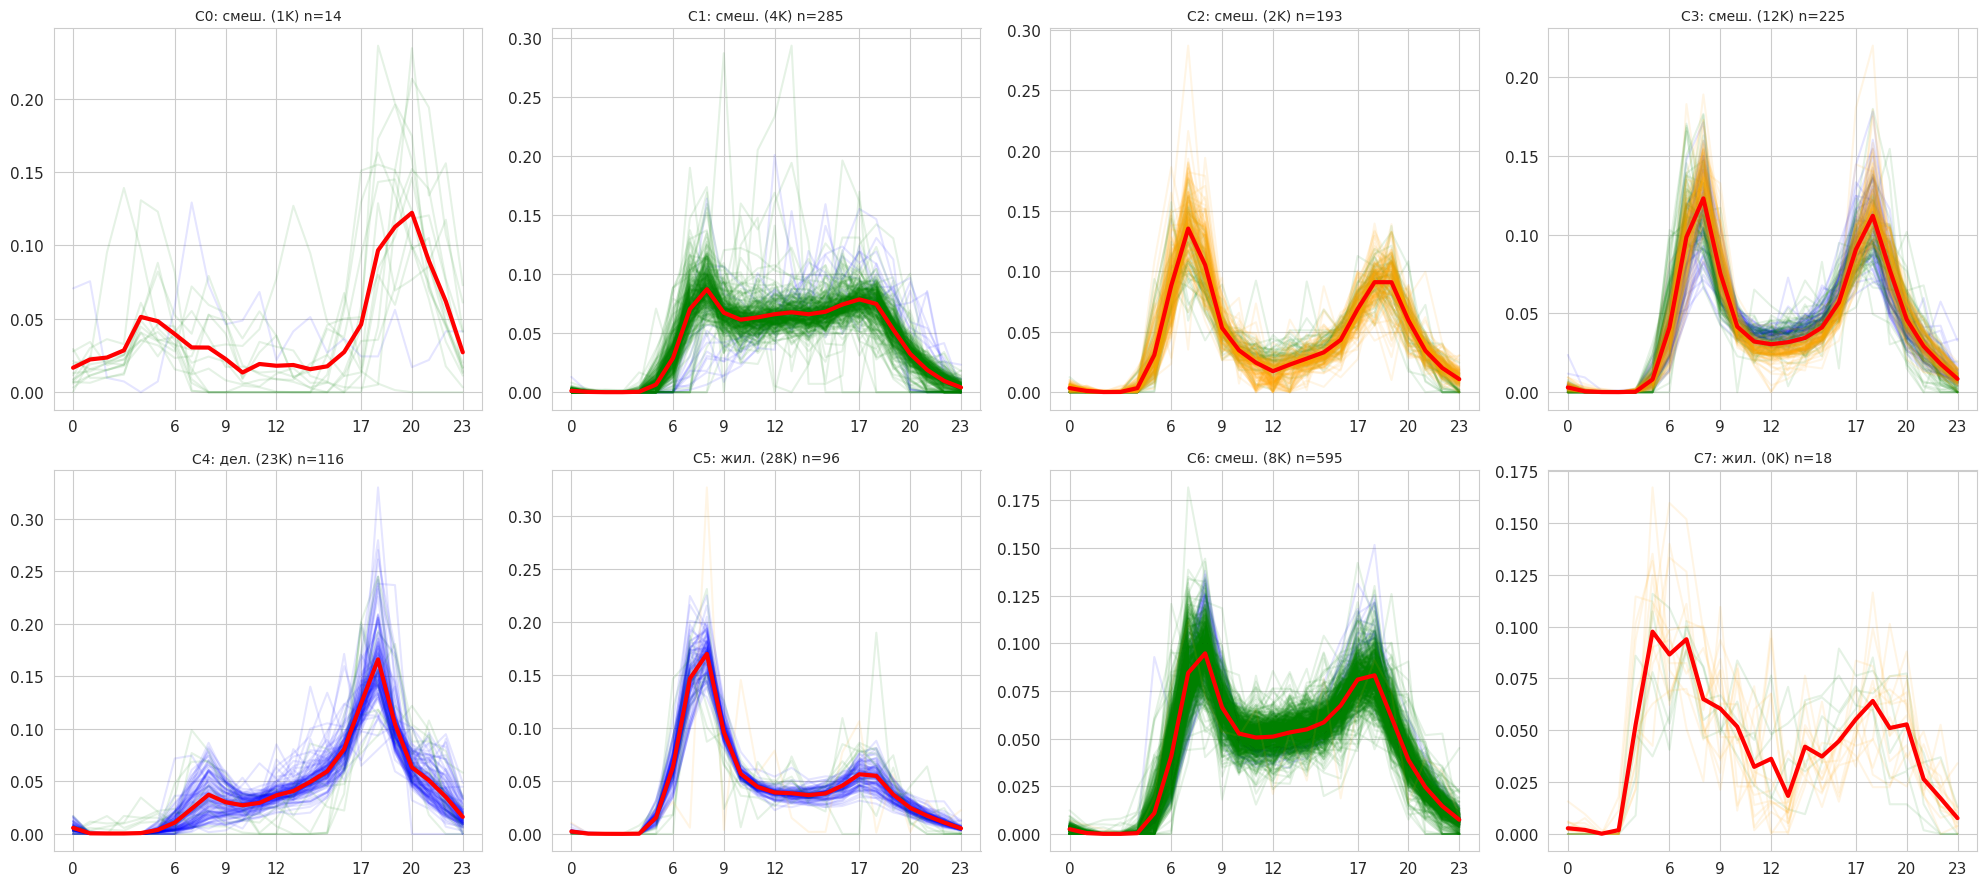

In [81]:
# визуализация профилей
ncols = (final_k + 1) // 2
fig, axes = plt.subplots(2, ncols, figsize=(5*ncols, 9))
axes = axes.ravel()

colors = {'Метро':'blue', 'НГПТ':'green', 'МЦД':'orange'}
for c in range(final_k):
    ax = axes[c]
    s = af[af.cluster==c]
    for _, r in s.iterrows():
        p = [r[f'wd_h{h}'] for h in range(24)]
        ax.plot(range(24), p, alpha=0.1, color=colors[r.transport])
    ax.plot(range(24), s[profile_cols].mean().values, 'r-', lw=3)
    me = s.morn_eve_ratio.mean()
    lab = "жил." if me>1.3 else ("дел." if me<0.75 else "смеш.")
    ax.set_title(f'C{c}: {lab} ({s.daily_volume.mean()/1000:.0f}K) n={len(s)}', fontsize=10)
    ax.set_xticks([0,6,9,12,17,20,23])

for i in range(final_k, len(axes)): axes[i].set_visible(False)
plt.tight_layout(); plt.savefig('./eda_output/clust_profiles.png', dpi=150); plt.show()

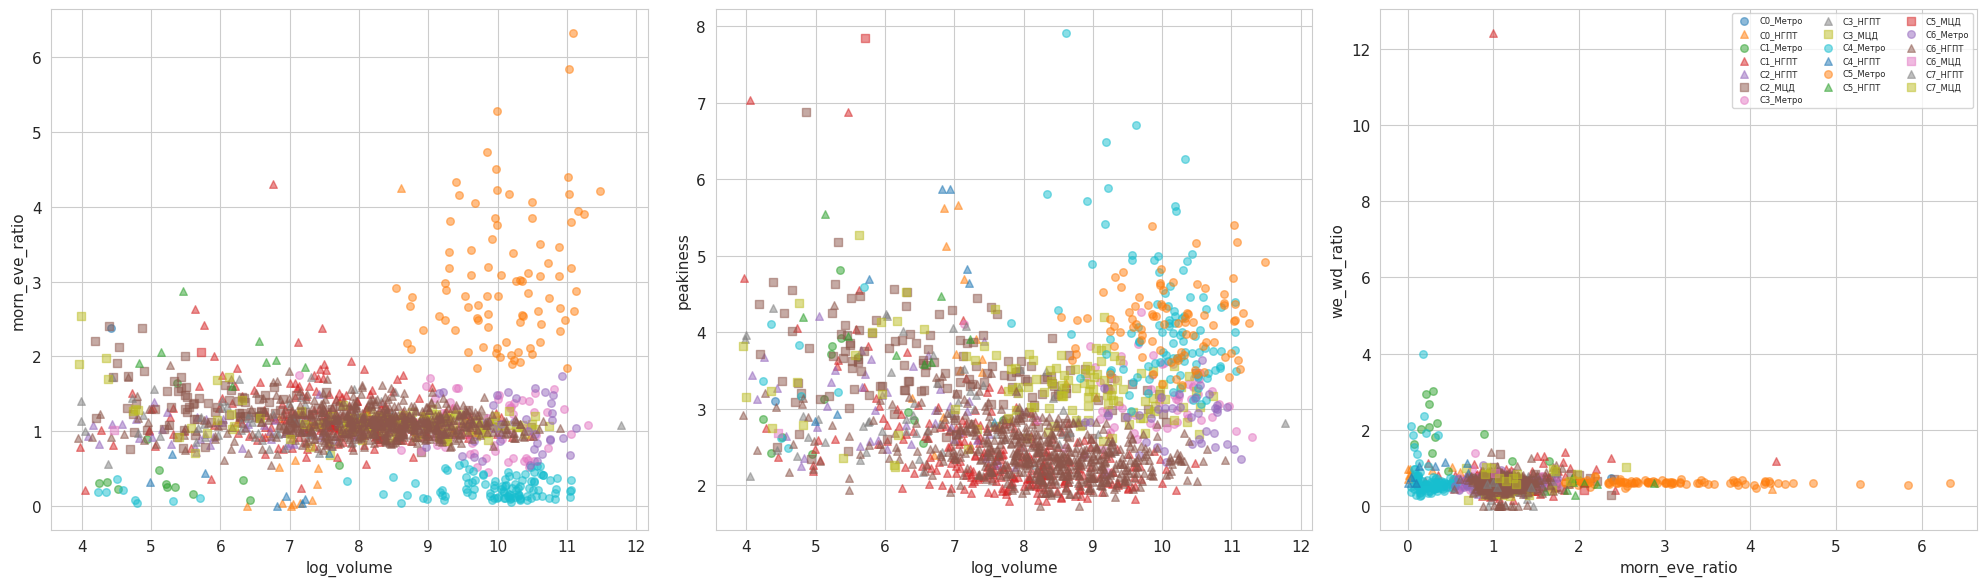

In [82]:
# scatter-проверка
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
combos = [('log_volume','morn_eve_ratio'), ('log_volume','peakiness'),
          ('morn_eve_ratio','we_wd_ratio')]
markers = {'Метро':'o', 'НГПТ':'^', 'МЦД':'s'}

for ax, (x, y) in zip(axes, combos):
    for c in sorted(af.cluster.unique()):
        for tr, mk in markers.items():
            sub = af[(af.cluster==c) & (af.transport==tr)]
            if len(sub): ax.scatter(sub[x], sub[y], marker=mk, s=30, alpha=0.5,
                                    label=f'C{c}_{tr}')
    ax.set_xlabel(x); ax.set_ylabel(y)
axes[2].legend(fontsize=6, ncol=3)
plt.tight_layout(); plt.savefig('./eda_output/clust_scatter.png', dpi=150); plt.show()

In [83]:
# именование + сохранение
os.makedirs('./eda_output', exist_ok=True)
hourly.to_parquet('./eda_output/hourly.parquet', index=False)

cluster_names = {}
for c in sorted(af.cluster.unique()):
    s = af[af.cluster==c]
    me, vol = s.morn_eve_ratio.mean(), s.daily_volume.mean()
    nm = "Жилой" if me>1.3 else ("Деловой" if me<0.75 else "Смешанный")
    nm += " крупный" if vol>20000 else (" средний" if vol>5000 else (" малый" if vol>1000 else " мелкий"))
    dom = s.transport.value_counts()
    if dom.iloc[0]/len(s) > 0.7: nm += f" ({dom.index[0]})"
    cluster_names[c] = nm

af['cluster_name'] = af.cluster.map(cluster_names)

save_cols = ['object_id','object_name','transport','cluster','cluster_name',
             'LN_CODE','LN_NAME','daily_volume','log_volume',
             'morn_eve_ratio','we_wd_ratio','peakiness','night_share','midday_share']
af[save_cols].to_csv('./eda_output/final_clusters.csv', index=False)
print(f"Сохранено: {len(af)} объектов, {final_k} кластеров")

Сохранено: 1542 объектов, 8 кластеров


---
# Бейзлайн-прогноз (24ч вперёд)
Модели: naive-варианты, ETS, k-NN (individual + cluster), ансамбль

In [84]:
OUTPUT_DIR = './eda_output/'
hourly = pd.read_parquet(f'{OUTPUT_DIR}hourly.parquet')
clusters = pd.read_csv(f'{OUTPUT_DIR}final_clusters.csv')

def clean_id(v):
    s = str(v)
    return s[:-2] if s.endswith('.0') else s

def get_obj_id(row):
    if pd.notna(row.get('BUS_RT_NO')): return f"RT_{clean_id(row['BUS_RT_NO'])}"
    if pd.notna(row.get('ST_CODE')): return f"ST_{clean_id(row['ST_CODE'])}"
    if pd.notna(row.get('PLACE_ID')): return f"PL_{clean_id(row['PLACE_ID'])}"
    return None

hourly['object_id'] = hourly.apply(get_obj_id, axis=1)
hourly = hourly[hourly.object_id.notna()]
ts_data = hourly.groupby(['date_hour','object_id'])['pax'].sum().reset_index()

clusters['object_id_str'] = clusters.transport.map(
    {'Метро':'ST_','МЦД':'ST_','НГПТ':'RT_'}) + clusters.object_id.apply(clean_id)

ts_data = ts_data.merge(
    clusters[['object_id_str','cluster','cluster_name','transport','daily_volume']]
    .rename(columns={'object_id_str':'object_id'}),
    on='object_id', how='left')

ts_data['hour'] = ts_data.date_hour.dt.hour
ts_data['dow'] = ts_data.date_hour.dt.dayofweek
ts_data['date'] = ts_data.date_hour.dt.date

ts_ids = set(ts_data.object_id.unique())
matched = ts_ids & set(clusters.object_id_str.unique())
print(f"ts объектов: {len(ts_ids)}, в кластерах: {len(clusters.object_id_str.unique())}, совпали: {len(matched)}")

ts объектов: 1659, в кластерах: 1542, совпали: 1542


## Вспомогательные функции и базовые модели

In [85]:
HORIZON = 24
N_HOURS = 168
dow_names = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

def prepare_ts(object_id, data=ts_data):
    d = data[data.object_id == object_id].copy()
    if len(d) == 0: return None
    full = pd.date_range(data.date_hour.min(), data.date_hour.max(), freq='h')
    return d.set_index('date_hour')['pax'].reindex(full, fill_value=0).rename_axis('datetime')

def get_folds(n=N_HOURS, h=HORIZON, min_days=2):
    return [{'te': t, 'ts': t, 'tf': t+h, 'td': t//24}
            for t in range(min_days*24, n-h+1, 24)]

def metrics(yt, yp, name=""):
    yt, yp = np.array(yt, float), np.array(yp, float)
    mae = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    smape = np.mean(2*np.abs(yt-yp) / (np.abs(yt)+np.abs(yp)+1e-8)) * 100
    nmae = mae / np.mean(yt) * 100 if np.mean(yt)>0 else np.nan
    return {'model':name, 'MAE':round(mae,2), 'RMSE':round(rmse,2),
            'SMAPE':round(smape,2), 'nMAE%':round(nmae,2)}

# --- базовые модели ---
def seasonal_naive(y, h, s=24):
    return np.array([y[-(s) + i%s] for i in range(h)])

def mean_profile(y, h, s=24):
    days = len(y)//s
    return np.tile(y[:days*s].reshape(days,s).mean(0), h//s+1)[:h]

def weighted_profile(y, h, s=24):
    days = len(y)//s
    d = y[:days*s].reshape(days,s)
    w = np.exp(np.linspace(-1,0,days)); w /= w.sum()
    return np.tile(np.average(d, axis=0, weights=w), h//s+1)[:h]

def same_type_day(y, h, test_dow, s=24):
    days = len(y)//s
    d = y[:days*s].reshape(days,s)
    is_we = test_dow >= 5
    idx = [i for i in range(days) if (i%7 >= 5) == is_we]
    prof = d[idx].mean(0) if idx else d.mean(0)
    return np.tile(prof, h//s+1)[:h]

def adjusted_naive(y, h, test_dow, s=24):
    pred = seasonal_naive(y, h, s)
    days = len(y)//s
    d = y[:days*s].reshape(days,s)
    yd = (days-1) % 7
    if (yd >= 5) != (test_dow >= 5):
        we_idx = [i for i in range(days) if i%7 >= 5]
        wd_idx = [i for i in range(days) if i%7 < 5]
        if we_idx and wd_idx:
            avg_we = d[we_idx].sum(1).mean()
            avg_wd = d[wd_idx].sum(1).mean()
            if test_dow >= 5 and avg_wd > 0:
                pred = pred * avg_we / avg_wd
            elif test_dow < 5 and avg_we > 0:
                pred = pred * avg_wd / avg_we
    return np.maximum(pred, 0)

## ETS с автоподбором

In [86]:
class ImprovedETS:
    def __init__(self, sp=24):
        self.sp = sp

    def fit_predict(self, y_train, steps, test_dow=None):
        y = np.array(y_train, float)
        sp = self.sp
        if len(y) < 2*sp:
            return mean_profile(y, steps, sp)

        # кандидаты
        cands = {
            'mean': mean_profile(y, steps, sp),
            'weighted': weighted_profile(y, steps, sp),
            'seasonal': seasonal_naive(y, steps, sp),
        }
        days = len(y)//sp
        cands['median'] = np.tile(np.median(y[:days*sp].reshape(days,sp), axis=0), steps//sp+1)[:steps]

        if test_dow is not None:
            cands['same_type'] = same_type_day(y, steps, test_dow, sp)
            cands['adjusted'] = adjusted_naive(y, steps, test_dow, sp)

        for stype in ['add', 'mul']:
            try:
                yf = np.maximum(y, 1) if stype=='mul' else y
                m = ExponentialSmoothing(yf, trend=None, seasonal=stype,
                    seasonal_periods=sp, initialization_method='estimated').fit(optimized=True)
                cands[f'ets_{stype}'] = m.forecast(steps)
            except: pass

        # валидация на последних 24ч
        y_val, y_sub = y[-sp:], y[:-sp]
        val_dow = (len(y_sub)//sp) % 7
        best_name, best_mae = 'mean', np.inf

        for nm in cands:
            try:
                if nm == 'seasonal': vp = seasonal_naive(y_sub, sp, sp)
                elif nm == 'mean': vp = mean_profile(y_sub, sp, sp)
                elif nm == 'weighted': vp = weighted_profile(y_sub, sp, sp)
                elif nm == 'median':
                    dd = len(y_sub)//sp
                    vp = np.median(y_sub[:dd*sp].reshape(dd,sp), axis=0)
                elif nm == 'same_type': vp = same_type_day(y_sub, sp, val_dow, sp)
                elif nm == 'adjusted': vp = adjusted_naive(y_sub, sp, val_dow, sp)
                elif 'ets' in nm:
                    st = 'mul' if 'mul' in nm else 'add'
                    yf = np.maximum(y_sub, 1) if st=='mul' else y_sub
                    vp = ExponentialSmoothing(yf, trend=None, seasonal=st,
                        seasonal_periods=sp, initialization_method='estimated').fit(optimized=True).forecast(sp)
                else: continue
                mae = np.mean(np.abs(y_val - vp[:len(y_val)]))
                if mae < best_mae: best_mae, best_name = mae, nm
            except: continue

        return np.maximum(cands.get(best_name, cands['mean']), 0)

## k-NN модели

In [87]:
class MinimalKNN:
    def __init__(self, k=3):
        self.k = k; self.scaler = StandardScaler()

    def fit(self, ts):
        v = ts.values
        self.mu = np.mean(v[v>0]) if (v>0).any() else 1
        X, y = [], []
        for i in range(24, len(v)):
            h = ts.index[i].hour
            X.append([np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24), v[i-24]/self.mu])
            y.append(v[i]/self.mu)
        X, y = np.array(X), np.array(y)
        self.scaler.fit(X)
        k = min(self.k, len(X)-1, 3)
        self.model = KNeighborsRegressor(max(k,1), weights='distance')
        self.model.fit(self.scaler.transform(X), y)
        self.vals, self.idx = v, ts.index
        return self

    def predict(self, steps):
        preds = []
        for i in range(steps):
            h = (self.idx[-1] + timedelta(hours=i+1)).hour
            li = len(self.vals)-24+i
            lag = self.vals[li]/self.mu if 0<=li<len(self.vals) else 1
            x = np.array([[np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24), lag]])
            preds.append(max(0, self.model.predict(self.scaler.transform(x))[0]*self.mu))
        return np.array(preds)


class ClusterKNN:
    def __init__(self, k=7):
        self.k = k; self.scaler = StandardScaler()

    def fit(self, series_dict, train_hours):
        X, y = [], []
        for ts in series_dict.values():
            v = ts.iloc[:train_hours].values
            mu = np.mean(v[v>0]) if (v>0).any() else 1
            for i in range(24, len(v)):
                h, d = ts.index[i].hour, ts.index[i].dayofweek
                X.append([np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24),
                          np.sin(2*np.pi*d/7), np.cos(2*np.pi*d/7), v[i-24]/mu])
                y.append(v[i]/mu)
        X, y = np.array(X), np.array(y)
        self.scaler.fit(X)
        self.model = KNeighborsRegressor(min(self.k, len(X)-1), weights='distance')
        self.model.fit(self.scaler.transform(X), y)
        return self

    def predict(self, ts_train, steps):
        v = ts_train.values
        mu = np.mean(v[v>0]) if (v>0).any() else 1
        preds = []
        for i in range(steps):
            ft = ts_train.index[-1] + timedelta(hours=i+1)
            li = len(v)-24+i
            lag = v[li]/mu if 0<=li<len(v) else 1
            x = np.array([[np.sin(2*np.pi*ft.hour/24), np.cos(2*np.pi*ft.hour/24),
                           np.sin(2*np.pi*ft.dayofweek/7), np.cos(2*np.pi*ft.dayofweek/7), lag]])
            preds.append(max(0, self.model.predict(self.scaler.transform(x))[0]*mu))
        return np.array(preds)

## Ансамбль (взвешенный по валидации)

In [88]:
class CleanEnsemble:
    def fit_predict(self, y_train, steps, test_dow):
        sp = 24
        if len(y_train) < 2*sp:
            return mean_profile(y_train, steps, sp)

        y_sub, y_val = y_train[:-sp], y_train[-sp:]
        vd = (len(y_sub)//sp) % 7

        models_val = {
            'seasonal': seasonal_naive(y_sub, sp, sp),
            'same_type': same_type_day(y_sub, sp, vd, sp),
            'adjusted': adjusted_naive(y_sub, sp, vd, sp),
            'weighted': weighted_profile(y_sub, sp, sp),
            'mean': mean_profile(y_sub, sp, sp),
        }
        scores = {n: mean_absolute_error(y_val, p[:len(y_val)])+1e-8
                  for n, p in models_val.items()}
        tot = sum(1/s for s in scores.values())
        w = {n: (1/s)/tot for n, s in scores.items()}

        models_test = {
            'seasonal': seasonal_naive(y_train, steps, sp),
            'same_type': same_type_day(y_train, steps, test_dow, sp),
            'adjusted': adjusted_naive(y_train, steps, test_dow, sp),
            'weighted': weighted_profile(y_train, steps, sp),
            'mean': mean_profile(y_train, steps, sp),
        }
        return np.maximum(sum(w[n]*models_test[n] for n in w), 0)

## Подготовка кластерных рядов + список объектов

In [89]:
cluster_series = {}
found = not_found = 0

for cid in clusters.cluster.unique():
    objs = clusters[clusters.cluster == cid]
    sd = {}
    for _, r in objs.iterrows():
        ts = prepare_ts(r.object_id_str)
        if ts is not None and ts.sum() > 0:
            sd[r.object_id_str] = ts; found += 1
        else: not_found += 1
    cluster_series[cid] = sd

print(f"Найдено: {found}, нет: {not_found}")
for cid in sorted(cluster_series):
    n = len(cluster_series[cid])
    orig = len(clusters[clusters.cluster==cid])
    print(f"  C{cid}: {n}/{orig}")

# объекты для оценки
all_obj = clusters[['object_id_str','object_name','cluster','transport','daily_volume']].rename(
    columns={'object_id_str':'object_id','object_name':'name'}).drop_duplicates('object_id')
all_obj = all_obj[all_obj.object_id.isin(ts_ids)].copy()
print(f"\nДля оценки: {len(all_obj)} объектов")

Найдено: 1542, нет: 0
  C0: 14/14
  C1: 285/285
  C2: 193/193
  C3: 225/225
  C4: 116/116
  C5: 96/96
  C6: 595/595
  C7: 18/18

Для оценки: 1542 объектов


## Основной цикл CV

In [90]:
folds = get_folds(min_days=2)
all_results = []
skipped = processed = 0

# кластерные k-NN — обучаем по разу на фолд
print("Обучаю кластерные k-NN...")
cknn_cache = {}
for fi, fold in enumerate(folds):
    cknn_cache[fi] = {}
    for cid, sd in cluster_series.items():
        if len(sd) < 5: continue
        cknn = ClusterKNN(7)
        cknn.fit(sd, fold['te'])
        cknn_cache[fi][cid] = cknn
    print(f"  fold {fi}: {len(cknn_cache[fi])} кластеров")

print(f"\nCV: {len(all_obj)} объектов × {len(folds)} фолдов")

for oi, (_, obj) in enumerate(all_obj.iterrows()):
    oid, cid = obj.object_id, obj.cluster
    ts = prepare_ts(oid)
    if ts is None or ts.sum() == 0:
        skipped += 1; continue

    done = False
    for fi, fold in enumerate(folds):
        y_tr = ts.iloc[:fold['te']].values
        y_te = ts.iloc[fold['ts']:fold['tf']].values
        ts_tr = ts.iloc[:fold['te']]
        if len(y_te)==0 or y_te.sum()==0: continue
        td = ts.index[fold['ts']].dayofweek

        preds = {
            'Seasonal Naive': seasonal_naive(y_tr, HORIZON),
            'Mean Profile': mean_profile(y_tr, HORIZON),
            'Weighted Profile': weighted_profile(y_tr, HORIZON),
            'Same-Type Day': same_type_day(y_tr, HORIZON, td),
            'Adjusted Naive': adjusted_naive(y_tr, HORIZON, td),
            'ETS': ImprovedETS().fit_predict(y_tr, HORIZON, td),
        }

        if len(y_tr) >= 48:
            try:
                knn = MinimalKNN(3).fit(ts_tr)
                preds['k-NN minimal'] = knn.predict(HORIZON)
            except: pass

        if fi in cknn_cache and cid in cknn_cache[fi]:
            try: preds['Cluster k-NN'] = cknn_cache[fi][cid].predict(ts_tr, HORIZON)
            except: pass

        try: preds['Clean Ensemble'] = CleanEnsemble().fit_predict(y_tr, HORIZON, td)
        except: pass

        for mn, pred in preds.items():
            m = metrics(y_te, pred, mn)
            m.update({'object_id':oid, 'cluster':cid, 'transport':obj.transport,
                      'volume':obj.daily_volume, 'fold':fi,
                      'test_day':dow_names[td], 'is_test_weekend':int(td>=5),
                      'train_days':fold['td']})
            all_results.append(m)
        done = True

    if done: processed += 1
    if (oi+1) % 200 == 0:
        print(f"  {oi+1}/{len(all_obj)} | done={processed} skip={skipped}")

results = pd.DataFrame(all_results)
print(f"\nГотово: {processed} обработано, {skipped} пропущено, {len(results):,} записей")

Обучаю кластерные k-NN...
  fold 0: 8 кластеров
  fold 1: 8 кластеров
  fold 2: 8 кластеров
  fold 3: 8 кластеров
  fold 4: 8 кластеров

CV: 1542 объектов × 5 фолдов
  200/1542 | done=200 skip=0
  400/1542 | done=400 skip=0
  600/1542 | done=600 skip=0
  800/1542 | done=800 skip=0
  1000/1542 | done=1000 skip=0
  1200/1542 | done=1200 skip=0
  1400/1542 | done=1400 skip=0

Готово: 1542 обработано, 0 пропущено, 69,147 записей


## Результаты

In [97]:
final = results.groupby('model').agg(
    MAE=('MAE','mean'), MAE_med=('MAE','median'), SMAPE=('SMAPE','mean'),
    nMAE=('nMAE%','mean'), n=('MAE','count')
).round(2).sort_values('MAE')

print("="*70)
print(f"РЕЙТИНГ ({results.object_id.nunique()} объектов × {len(folds)} фолдов)")
print("="*70)
for i, (m, r) in enumerate(final.iterrows()):
    medal = ['1','2','3'][i] if i<3 else '  '
    print(f"  {medal} {m:<20} MAE={r.MAE:>7.2f} (med={r.MAE_med:>6.2f})  SMAPE={r.SMAPE:>5.2f}%")

РЕЙТИНГ (1542 объектов × 5 фолдов)
  1 Same-Type Day        MAE=  62.16 (med= 25.71)  SMAPE=31.74%
  2 Adjusted Naive       MAE=  62.33 (med= 28.38)  SMAPE=32.04%
  3 Seasonal Naive       MAE=  62.33 (med= 28.38)  SMAPE=32.04%
     Cluster k-NN         MAE=  64.17 (med= 29.80)  SMAPE=44.42%
     ETS                  MAE=  68.59 (med= 28.07)  SMAPE=35.90%
     Clean Ensemble       MAE=  69.54 (med= 28.36)  SMAPE=34.42%
     k-NN minimal         MAE=  70.36 (med= 30.75)  SMAPE=35.10%
     Weighted Profile     MAE=  82.65 (med= 29.81)  SMAPE=36.25%
     Mean Profile         MAE=  85.77 (med= 29.87)  SMAPE=36.53%


In [98]:
# --- разрезы ---
print("\n--- ПО ТРАНСПОРТУ ---")
for tr in ['Метро','НГПТ','МЦД']:
    sub = results[results.transport==tr]
    if len(sub)==0: continue
    s = sub.groupby('model')['MAE'].mean().sort_values()
    print(f"\n{tr} ({sub.object_id.nunique()} объектов):")
    for j, (m, v) in enumerate(s.head(3).items()):
        print(f"  {'123'[j] if j<3 else ' '} {m:<20} {v:.2f}")

print("\n--- БУДНИ vs ВЫХОДНЫЕ ---")
for lbl, mask in [('БУДНИ', results.is_test_weekend==0), ('ВЫХОДНЫЕ', results.is_test_weekend==1)]:
    s = results[mask].groupby('model')['MAE'].mean().sort_values()
    print(f"\n{lbl}:")
    for j, (m, v) in enumerate(s.head(3).items()):
        print(f"  {m:<20} {v:.2f}")

print("\n--- ПО КЛАСТЕРАМ ---")
for cid in sorted(results.cluster.dropna().unique()):
    s = results[results.cluster==cid]
    best = s.groupby('model')['MAE'].mean().sort_values().head(1)
    print(f"  C{int(cid)} ({s.object_id.nunique()} объектов): {best.index[0]} MAE={best.values[0]:.2f}")

print("\n--- ПО МАСШТАБУ ---")
results['vol_grp'] = pd.cut(results.volume, [0,1000,5000,20000,50000,np.inf],
                             labels=['<1K','1-5K','5-20K','20-50K','>50K'])
for g in ['<1K','1-5K','5-20K','20-50K','>50K']:
    sub = results[results.vol_grp==g]
    if len(sub)==0: continue
    s = sub.groupby('model')['MAE'].mean().sort_values()
    print(f"\n{g} ({sub.object_id.nunique()}):")
    for j, (m, v) in enumerate(s.head(3).items()):
        print(f"  {m:<20} {v:.2f}")


--- ПО ТРАНСПОРТУ ---

Метро (312 объектов):
  1 Adjusted Naive       151.89
  2 Seasonal Naive       151.89
  3 Same-Type Day        155.38

НГПТ (958 объектов):
  1 Same-Type Day        38.10
  2 Cluster k-NN         39.53
  3 Seasonal Naive       39.68

МЦД (272 объектов):
  1 Cluster k-NN         38.45
  2 Adjusted Naive       38.91
  3 Seasonal Naive       38.91

--- БУДНИ vs ВЫХОДНЫЕ ---

БУДНИ:
  Same-Type Day        33.63
  Mean Profile         33.63
  Weighted Profile     33.76

ВЫХОДНЫЕ:
  Cluster k-NN         97.35
  Adjusted Naive       100.08
  Seasonal Naive       100.08

--- ПО КЛАСТЕРАМ ---
  C0 (14 объектов): ETS MAE=21.29
  C1 (285 объектов): Same-Type Day MAE=31.18
  C2 (193 объектов): Same-Type Day MAE=18.47
  C3 (225 объектов): Cluster k-NN MAE=77.13
  C4 (116 объектов): Adjusted Naive MAE=157.50
  C5 (96 объектов): Cluster k-NN MAE=137.50
  C6 (595 объектов): Same-Type Day MAE=54.02
  C7 (18 объектов): Same-Type Day MAE=3.49

--- ПО МАСШТАБУ ---

<1K (296):
  Sam

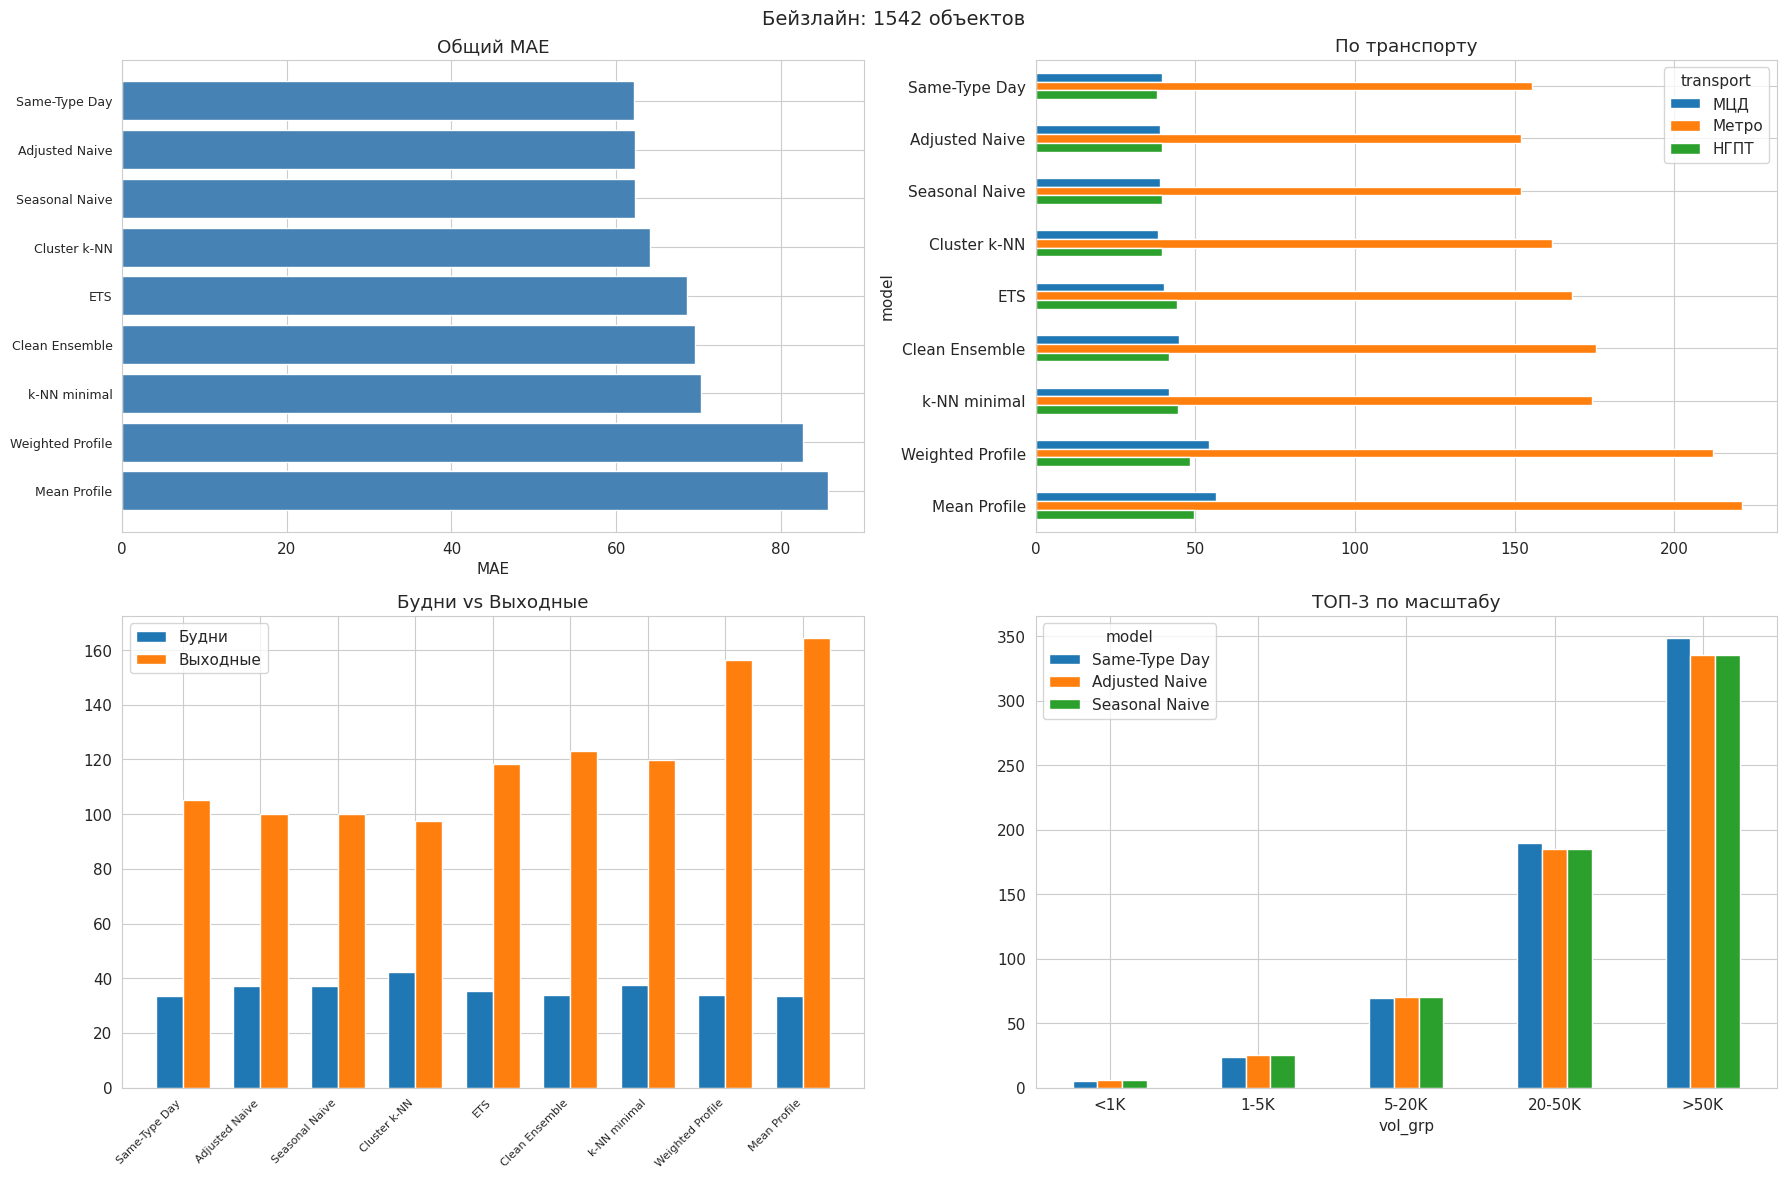

In [93]:
# сводные графики
models_order = final.index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0,0].barh(range(len(final)), final.MAE.values, color='steelblue')
axes[0,0].set_yticks(range(len(final))); axes[0,0].set_yticklabels(models_order, fontsize=9)
axes[0,0].set_xlabel('MAE'); axes[0,0].set_title('Общий MAE'); axes[0,0].invert_yaxis()

tp = results.pivot_table('MAE', 'model', 'transport', 'mean').reindex(models_order)
tp.plot(kind='barh', ax=axes[0,1]); axes[0,1].set_title('По транспорту'); axes[0,1].invert_yaxis()

wd = results[results.is_test_weekend==0].groupby('model')['MAE'].mean()
we = results[results.is_test_weekend==1].groupby('model')['MAE'].mean()
x = range(len(models_order)); w = 0.35
axes[1,0].bar([i-w/2 for i in x], [wd.get(m,0) for m in models_order], w, label='Будни')
axes[1,0].bar([i+w/2 for i in x], [we.get(m,0) for m in models_order], w, label='Выходные')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(models_order, rotation=45, ha='right', fontsize=8)
axes[1,0].legend(); axes[1,0].set_title('Будни vs Выходные')

vp = results.pivot_table('MAE', 'vol_grp', 'model', 'mean')
vp[models_order[:3]].plot(kind='bar', ax=axes[1,1], rot=0)
axes[1,1].set_title('ТОП-3 по масштабу')

plt.suptitle(f'Бейзлайн: {results.object_id.nunique()} объектов', fontsize=14)
plt.tight_layout(); plt.savefig('./eda_output/baseline_final.png', dpi=150); plt.show()

## Примеры прогнозов (топ-12 по объёму)

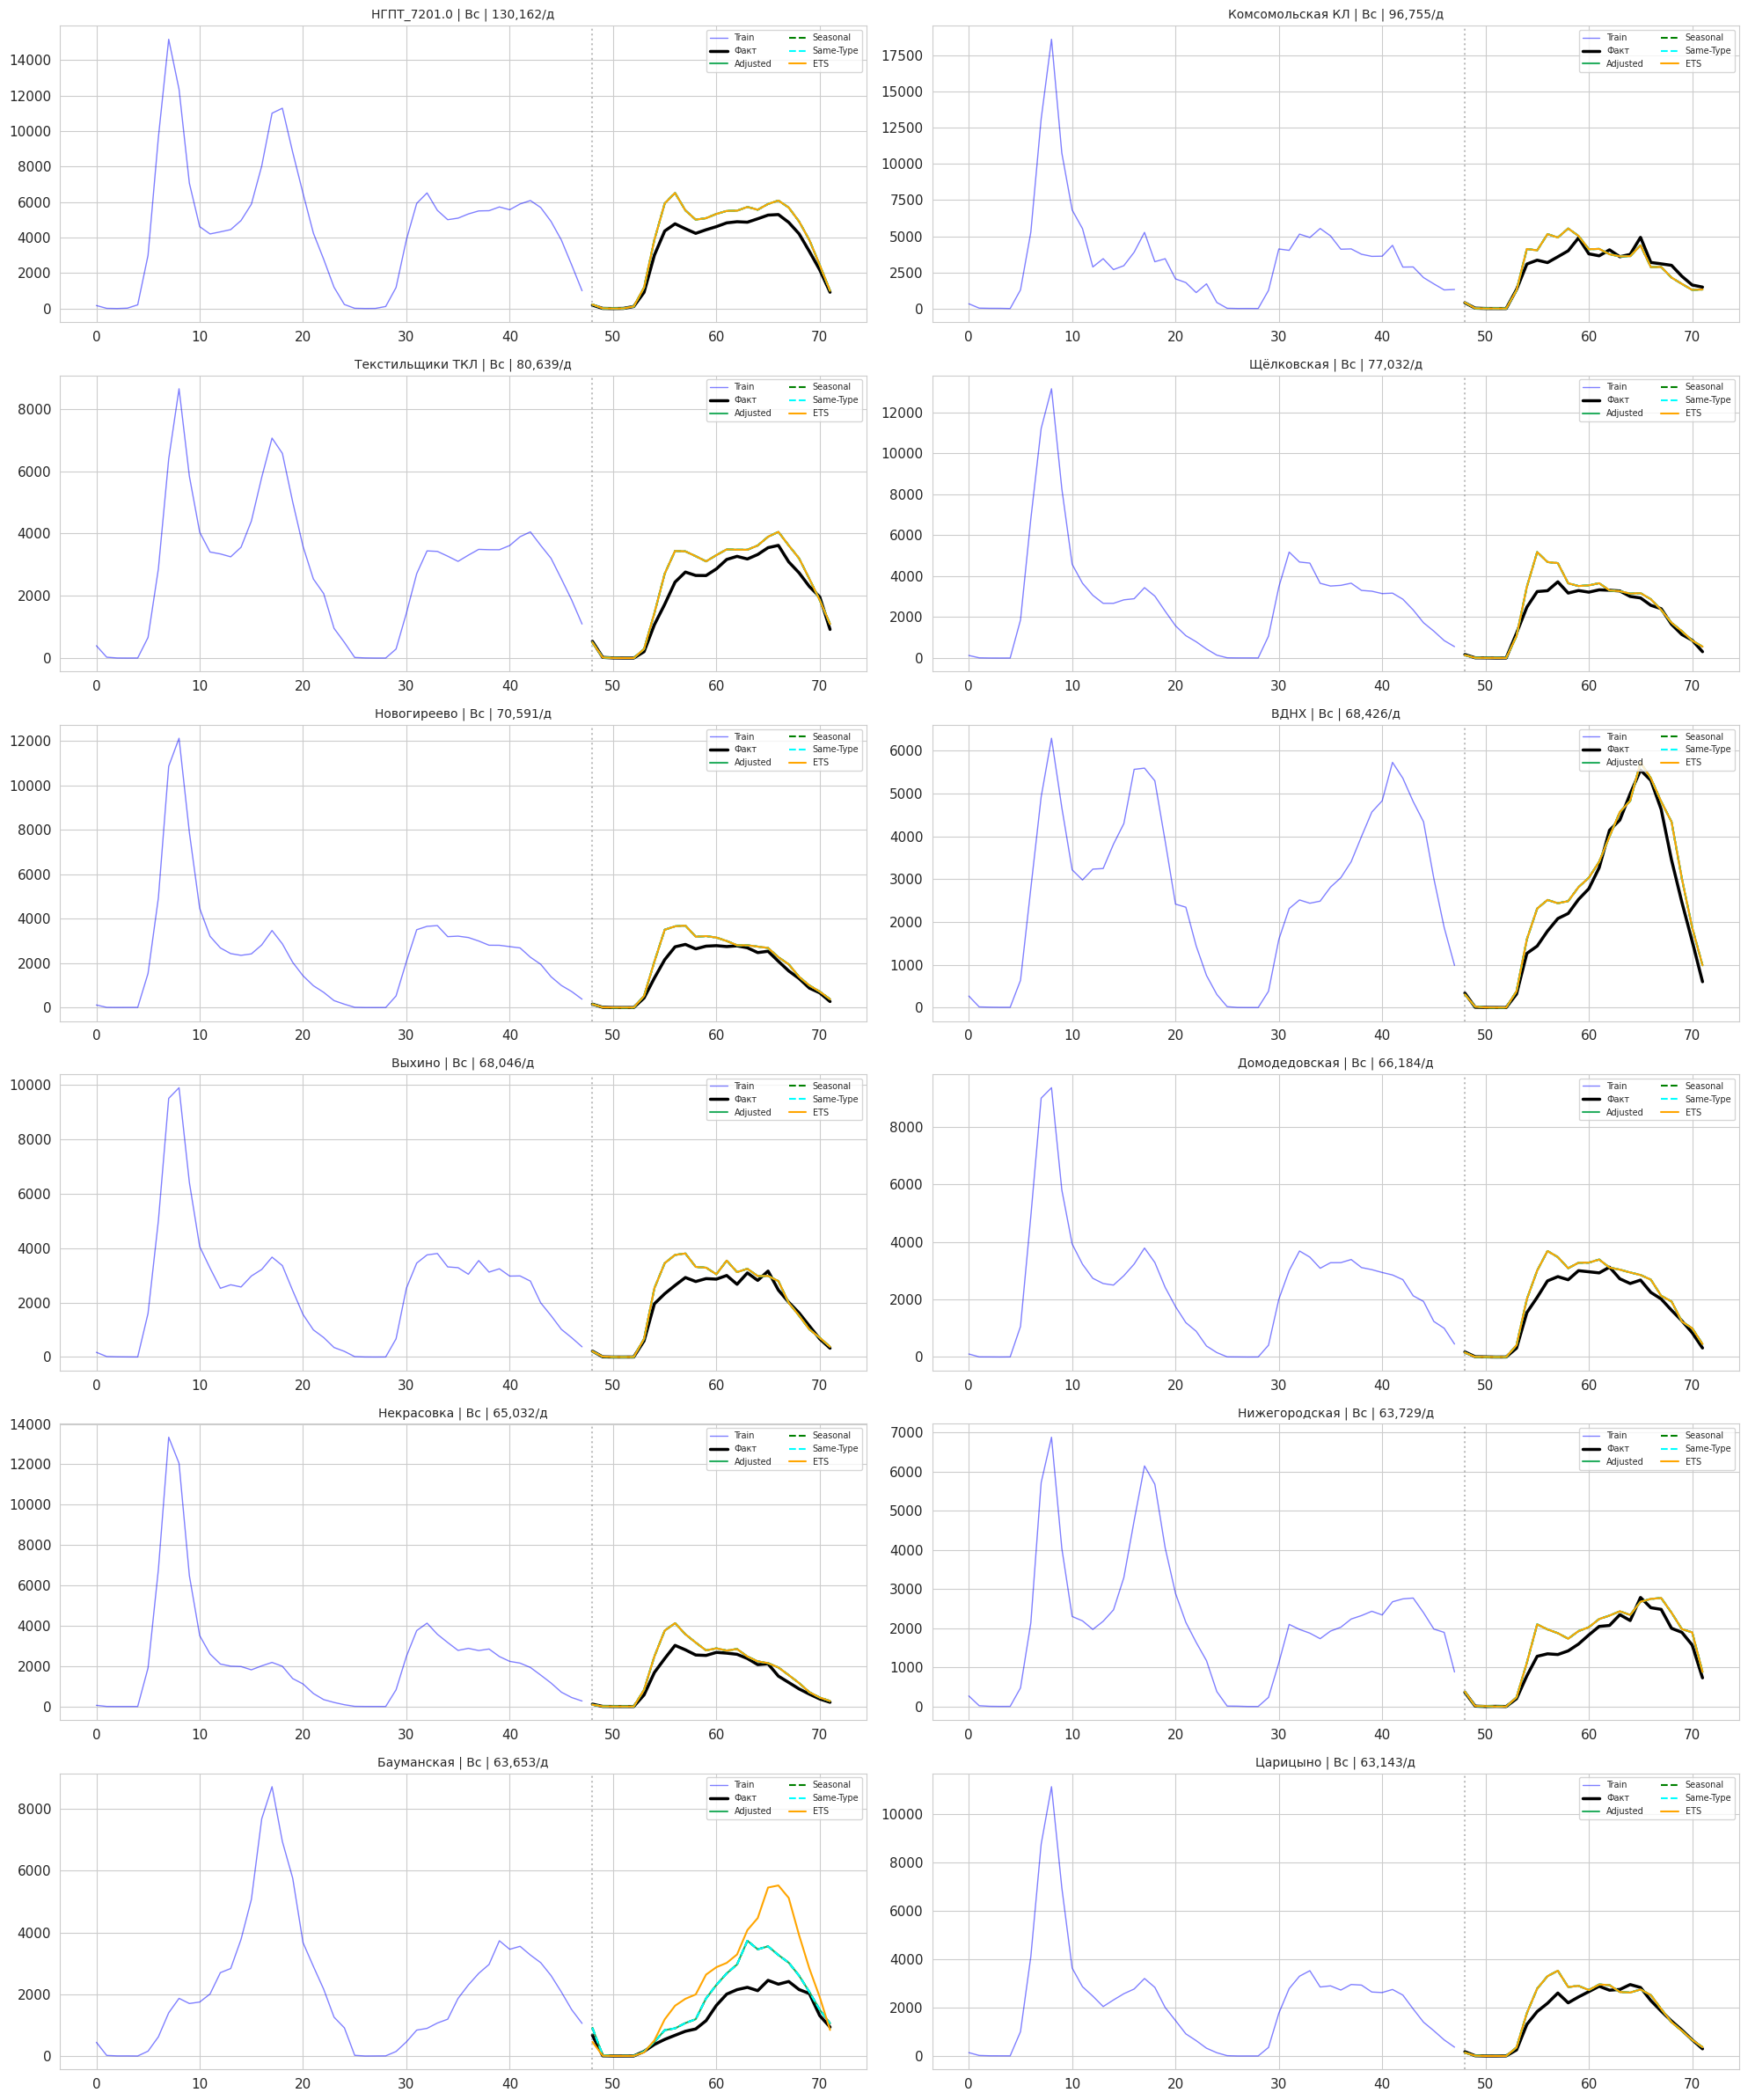

In [94]:
test_obj = all_obj.nlargest(12, 'daily_volume')
last_fold = folds[-1]

fig, axes = plt.subplots(6, 2, figsize=(20, 24))
axes = axes.ravel()

for idx, (_, obj) in enumerate(test_obj.iterrows()):
    if idx >= 12: break
    ax = axes[idx]
    ts = prepare_ts(obj.object_id)
    if ts is None: continue

    y_tr = ts.iloc[:last_fold['te']]
    y_te = ts.iloc[last_fold['ts']:last_fold['tf']].values
    td = ts.index[last_fold['ts']].dayofweek

    show = 48
    tr_show = y_tr.values[-show:]
    tr_x = range(show)
    te_x = range(show, show+len(y_te))

    ax.plot(tr_x, tr_show, 'b-', lw=1, alpha=.5, label='Train')
    ax.plot(te_x, y_te, 'k-', lw=2.5, label='Факт')
    ax.axvline(show, color='gray', ls=':', alpha=.5)

    for nm, fn, col, ls in [
        ('Adjusted',  lambda: adjusted_naive(y_tr.values, HORIZON, td), '#27ae60', '-'),
        ('Seasonal',  lambda: seasonal_naive(y_tr.values, HORIZON), 'green', '--'),
        ('Same-Type', lambda: same_type_day(y_tr.values, HORIZON, td), 'cyan', '--'),
        ('ETS',       lambda: ImprovedETS().fit_predict(y_tr.values, HORIZON, td), 'orange', '-'),
    ]:
        ax.plot(te_x, fn(), color=col, ls=ls, lw=1.5, label=nm)

    name_s = str(obj['name'])[:35] if pd.notna(obj['name']) else obj.object_id
    ax.set_title(f"{name_s} | {dow_names[td]} | {obj.daily_volume:,.0f}/д", fontsize=10)
    ax.legend(fontsize=7, ncol=2, loc='upper right')

plt.tight_layout(); plt.savefig('./eda_output/baseline_forecasts.png', dpi=150); plt.show()

In [95]:
results.to_csv('./eda_output/baseline_results_final.csv', index=False)
final.to_csv('./eda_output/baseline_summary_final.csv')
print(f"Сохранено: {len(results):,} записей, {results.object_id.nunique()} объектов, {results.model.nunique()} моделей")

Сохранено: 69,147 записей, 1542 объектов, 9 моделей


# Выводы

**Лучшая модель — Same-Type Day** (MAE = 62.16, SMAPE = 31.7%), лишь незначительно опережающая Seasonal Naive и Adjusted Naive. ML-модели (k-NN, ETS, ансамбль) не превзошли наивные подходы — на 7 днях обучения сложным моделям не хватает данных.

**Главные закономерности:**
- Суточная сезонность — доминирующий паттерн, простого разделения на будни/выходные достаточно для базовой точности
- На **выходных** ошибка втрое выше, чем на буднях (MAE ~100 vs ~34)
- **Метро** прогнозировать сложнее (MAE ~152) из-за высоких объёмов; для **МЦД** лучше работает кластерный k-NN
- Абсолютная ошибка растёт с масштабом объекта, но относительная точность сопоставима

**Для улучшения** необходимы: больше исторических данных, внешние признаки (праздники, погода) и более сложные модели (LSTM, Transformer).